In [1]:
import os
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')
import registrator
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from cil.io import TIFFStackReader
import importlib
import plot_library as pl

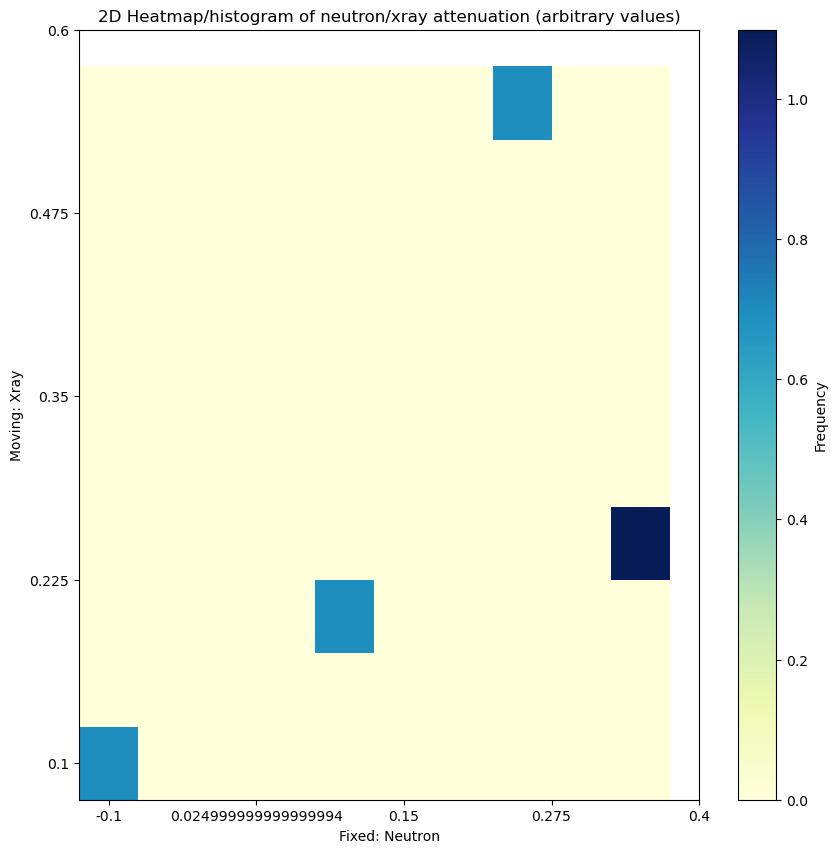

In [15]:
fixed_values = np.array([-0.1,0.1,0.4,0.3,0.4])
moving_values = np.array([0.1,0.2,0.3,0.6,0.3])
heatmap, xedges, yedges = np.histogram2d(fixed_values, moving_values, bins=(10, 10),
    range=[[fixed_values.min(), fixed_values.max()], [moving_values.min(), moving_values.max()]])
log_heatmap = np.log1p(heatmap)


# Plot the heatmap
plt.figure(figsize=(10, 10))
plt.imshow(log_heatmap.T, origin='lower', aspect='auto', cmap='YlGnBu')
plt.colorbar(label='Frequency')
plt.title('2D Heatmap/histogram of neutron/xray attenuation (arbitrary values)')
plt.xlabel('Fixed: Neutron')
plt.ylabel('Moving: Xray')
x_tick_positions = np.linspace(0, len(xedges) - 1, num=5)  # Choose 5 ticks
x_tick_labels = np.linspace(fixed_values.min(), fixed_values.max(), num=5)

# For the y-axis (moving values)
y_tick_positions = np.linspace(0, len(yedges) - 1, num=5)  # Choose 5 ticks
y_tick_labels = np.linspace(moving_values.min(), moving_values.max(), num=5)

# Set the tick labels on both axes
plt.xticks(x_tick_positions, x_tick_labels)
plt.yticks(y_tick_positions, y_tick_labels)
plt.show()

In [12]:

#filename = '/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/resized_XA_NA.json'
#meta_fixed, meta_moving, transform = registrator.load_data(filename)

In [13]:
reconpath0 = "/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_stitch_total.tif"
reconpath1 = "/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_reslice_itksnap.tif"
reconpath_neutron = "/dtu-compute/msaca/sliceA_neutron_psi/My_reconstructions/"


Number of slices: 1412
(1392, 280)


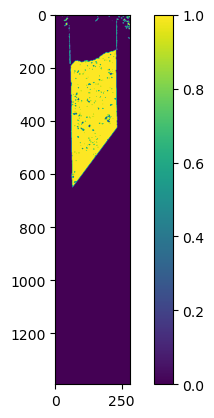

In [28]:
import tifffile

# Path to your large TIFF file
file_path = reconpath1

# Open the TIFF file
with tifffile.TiffFile(file_path) as tiff:
    # Print the number of slices (pages) in the volume
    print(f"Number of slices: {len(tiff.pages)}")
    
    # Access a specific slice (e.g., slice 10)
    slice_index = 1220
    slice_data = tiff.pages[slice_index].asarray()

# Now, `slice_data` contains the 2D array for the requested slice
print(slice_data.shape)

plt.imshow(slice_data>0.3)
plt.colorbar()

Number of slices: 3985
(3020, 670)


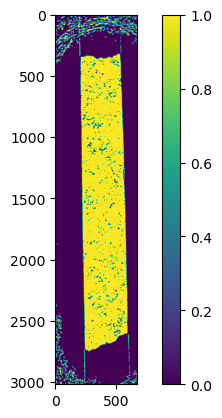

In [35]:
import tifffile

# Path to your large TIFF file
file_path = reconpath0

# Open the TIFF file
with tifffile.TiffFile(file_path) as tiff:
    # Print the number of slices (pages) in the volume
    print(f"Number of slices: {len(tiff.pages)}")
    
    # Access a specific slice (e.g., slice 10)
    slice_index = 2700
    slice_data = tiff.pages[slice_index].asarray()

# Now, `slice_data` contains the 2D array for the requested slice
print(slice_data.shape)

plt.imshow(slice_data>0.3)
plt.colorbar()

In [ ]:

recon_xray_ = sitk.ReadImage(reconpath0)
recon_xray_ = sitk.GetArrayFromImage(recon_xray_)
recon_xray = pl.array_normalizer(recon_xray_.astype(np.float32))
reader = TIFFStackReader(reconpath_neutron)
recon_neutron = pl.array_normalizer(reader.read())

In [9]:
importlib.reload(registrator)
reg = registrator.Registrator()
reg.load_images(fixed_array=recon_neutron,moving_array=recon_xray)

In [10]:
reg.resample(transform,ignore_flag = True)

Resampling the transformation
Resampling moving image


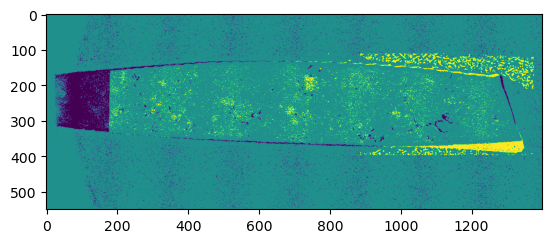

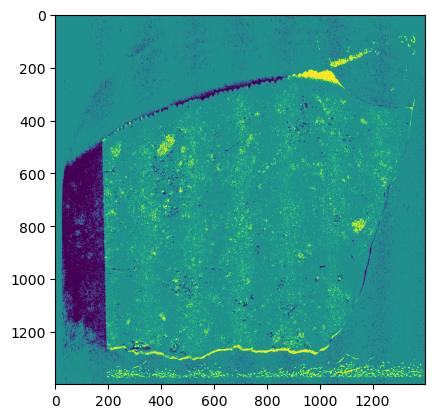

(1398, 550, 1400)


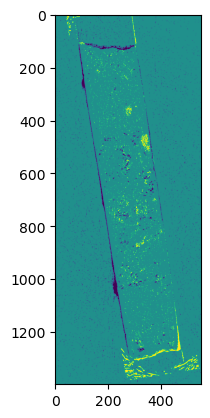

In [12]:
threshold = [0.5,0.32]
plt.imshow(1*(reg.as_array(reg.moving)[430]>threshold[1]) - 1*(reg.as_array(reg.fixed)[430]>threshold[0]))
plt.show()

plt.imshow(1*(reg.as_array(reg.moving)[:,340]>threshold[1]) - 1*(reg.as_array(reg.fixed)[:,340]>threshold[0]))
plt.show()


plt.imshow(1*(reg.as_array(reg.moving)[:,:,430]>threshold[1]) - 1*(reg.as_array(reg.fixed)[:,:,430]>threshold[0]))

print(np.shape(reg.as_array(reg.fixed)))
plt.show()